# Agrupamento de Coordenadas

### Objetivo

Reduzir a granularidade espacial da base original de ocorrências de furtos e roubos da RMSP, agrupando ocorrências próximas em regiões comuns. Com isso, o modelo consegue capturar **padrões criminais por região**, em vez de tratar cada ponto isolado como uma unidade independente.

### Abordagem: grade hexagonal H3

Cada par de coordenadas (latitude, longitude) é convertido no código da célula H3 em que cai. Ocorrências na mesma célula passam a compartilhar o mesmo identificador, e a análise segue por agregações sobre essa coluna.

Vantagens da escolha:

- **Identificadores estáveis**: a mesma célula vale para treino, validação, teste e dados futuros.
- **Sem vazamento de dados**: a conversão é determinística e não aprende nada com a base.
- **Vizinhança uniforme**: os 6 vizinhos de um hexágono ficam à mesma distância, o que facilita features do entorno.

### Decisão: a resolução H3 será definida antes do treinamento

A resolução **não** será tratada como hiperparâmetro dos modelos. Uma busca de hiperparâmetros deve alterar apenas o modelo, e não a natureza dos dados, que é exatamente o que a resolução faz: ao mudá-la, mudam a unidade de análise, o alvo e a dificuldade do problema. Por isso, as métricas de resoluções diferentes não são diretamente comparáveis.

In [1]:
import h3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv('datasets/database_processed.csv')

Como o objetivo é estimar o risco de furtos e roubos por região ou bairro, serão avaliadas as resoluções H3 **4, 5, 6, 7, 8 e 9**, e a escolha final virá da densidade dos dados e da persistência temporal.

In [3]:
def diagnostico(df, res):
    d = df.copy()
    d["h3"] = [h3.latlng_to_cell(la, lo, res) for la, lo in zip(d["LATITUDE"], d["LONGITUDE"])]

    por_celula = d.groupby("h3").size()
    por_cel_mes = d.groupby(["h3", "ANO_BO", "MES_BO"]).size()

    n_cel = por_celula.size
    n_meses = d[["ANO_BO", "MES_BO"]].drop_duplicates().shape[0]
    preenchimento = len(por_cel_mes) / (n_cel * n_meses)

    return {
        "res": res,
        "celulas": n_cel,
        "mediana_furtos_por_celula": por_celula.median(),
        "media_furtos_por_celula_mes": por_cel_mes.mean() * round(100 * preenchimento, 1) / 100,
        "pct_celula_mes_nao_vazia": round(100 * preenchimento, 1),
    }

In [4]:
results_resolutions = pd.DataFrame([diagnostico(df_raw, r) for r in [4, 5, 6, 7, 8, 9]])

In [5]:
results_resolutions

,res,celulas,mediana_furtos_por_celula,media_furtos_por_celula_mes,pct_celula_mes_nao_vazia
0,4,46,1.0,721.541129,22.5
1,5,93,2.0,356.604282,39.0
2,6,272,102.0,121.918447,60.1
3,7,1222,58.0,27.118977,56.7
4,8,5628,34.5,5.885621,51.8
5,9,24412,29.0,1.356791,45.3


In [6]:
def heatmap_corr(corr, titulo="", ax=None, vmin=0, vmax=1):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(corr.values, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(corr.columns)), labels=corr.columns)
    ax.set_yticks(range(len(corr.index)), labels=corr.index)
    ax.set_title(titulo)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < (vmin + vmax) / 2 + 0.2 else "black")
    return im

In [7]:
def persistencia(df, res):
    d = df.copy()
    d["h3"] = [h3.latlng_to_cell(la, lo, res) for la, lo in zip(d["LATITUDE"], d["LONGITUDE"])]
    anual = d.groupby(["h3", "ANO_BO"]).size().unstack(fill_value=0)
    return anual.corr(method="spearman")

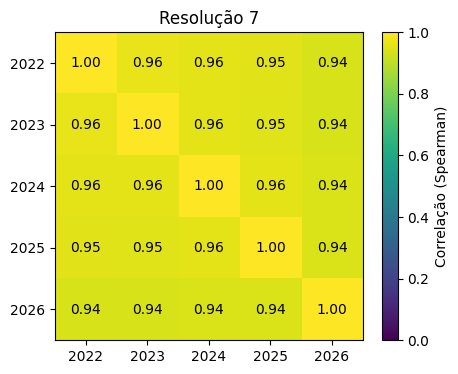

In [8]:
im = heatmap_corr(persistencia(df_raw, 7), "Resolução 7")
plt.colorbar(im, label="Correlação (Spearman)")
plt.show()

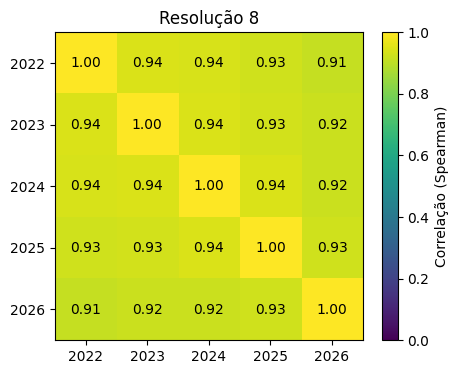

In [9]:
im = heatmap_corr(persistencia(df_raw, 8), "Resolução 8")
plt.colorbar(im, label="Correlação (Spearman)")
plt.show()

## Definição da resolução H3

Será adotada a resolução **7** do sistema H3 (células de ~1,2 km de aresta), pelos seguintes motivos:

- **Persistência temporal alta**: a correlação de Spearman entre anos consecutivos fica em torno de 0,95, o que indica que o padrão espacial de ocorrências se mantém ao longo do tempo.
- **Preenchimento razoável**: cerca de 57% das combinações célula × mês têm ao menos uma ocorrência.
- **Volume mensal adequado**: a média é de aproximadamente 27 ocorrências por célula e mês, o que reduz o efeito do acaso sobre o alvo de risco.

In [10]:
df_raw["h3"] = [h3.latlng_to_cell(la, lo, 7) for la, lo in zip(df_raw["LATITUDE"], df_raw["LONGITUDE"])]

In [11]:
df_raw.head()

,LATITUDE,LONGITUDE,DATA,city,MES_BO,ANO_BO,cnt_crime,FURTO,ROUBO,h3
0,-28.304600,-54.271865,1-12-2024,GUARULHOS,12,2024,1,1,0,87a97228dffffff
1,-24.972870,-48.402852,2-10-2025,TABOAO DA SERRA,10,2025,1,0,1,87a806c14ffffff
2,-24.972870,-48.402852,2-11-2025,EMBU DAS ARTES,11,2025,1,0,1,87a806c14ffffff
3,-24.969331,-48.361020,2-2-2024,ITAPECERICA DA SERRA,2,2024,1,0,1,87a806d8bffffff
4,-24.969324,-48.361338,1-7-2023,JUQUITIBA,7,2023,1,0,1,87a806d8bffffff


**Salvar**

In [12]:
df_raw.to_csv('datasets/database_processed_h3.csv', index=False)